# 🛡️ DeepGuard — Notebook 3: Improved Ensemble (XGBoost + IF + Autoencoder)
**IBM AML Dataset** | Iqra University FYP 2023 | Supervisor: Dr. Dure e Jabeen

> Run **Notebook 1** first so `/content/preprocessed/` exists (or upload `preprocessed.zip` below).
> This notebook adds a **supervised XGBoost model** (you already have fraud labels — Notebooks 1–2
> only used them for evaluation, not training) and re-tunes the ensemble on a proper validation
> split. See `IMPROVEMENTS.md` for the full write-up of what changed and why.
>
> ⚡ Enable GPU: Runtime → Change runtime type → T4 GPU (optional, speeds up the autoencoder)

In [1]:
# ── Install dependencies ──
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow xgboost shap joblib -q
import tensorflow as tf
print(f"✅ TensorFlow: {tf.__version__}")
print(f"✅ GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

✅ TensorFlow: 2.20.0
✅ GPU Available: True


>  🔌 **Colab disconnect protection — read this first.** This notebook takes 20–30+ minutes end to end (Autoencoder training + 40-trial Optuna search are the slow parts), and free-tier Colab disconnects on idle timeouts. A disconnect wipes the kernel's memory — the notebook *display* keeps showing old outputs, which looks like progress is still there, but every variable is gone. **This cell mounts Google Drive and checkpoints the two expensive results as soon as they finish, so a disconnect costs you a re-run of a couple of quick cells, not the full 20+ minutes.** Run it once at the start of every session.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
CHECKPOINT_DIR = '/content/drive/MyDrive/deepguard_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"✅ Checkpoints will be saved to {CHECKPOINT_DIR}")
print("   (survives disconnects — next session, re-run cells top to bottom as normal;")
print("   the checkpointed cells will detect existing files and skip straight to loading them)")

Mounted at /content/drive
✅ Checkpoints will be saved to /content/drive/MyDrive/deepguard_checkpoints
   (survives disconnects — next session, re-run cells top to bottom as normal;
   the checkpointed cells will detect existing files and skip straight to loading them)


## 📂 Step 1 — Load Preprocessed Data
This now checks Google Drive first (from the checkpoint cell above) — if you've run Notebook 1 and landed here before, your preprocessed data is cached in Drive and loads in seconds. First time only, it'll ask you to upload `preprocessed.zip` once, then cache it for every session after.

In [3]:
# 🔧 If you already have Notebook 1's output somewhere in Drive, point this at it directly
# (the exact folder that CONTAINS X_train.npy, X_test.npy, scaler.pkl, feature_cols.pkl —
# not a parent folder). Leave as None to use the default checkpoint location instead.
# PREPROCESSED_DRIVE_OVERRIDE = '/content/drive/MyDrive/preprossessed/content/processed'  # 🔧 adjust if wrong
PREPROCESSED_DRIVE_OVERRIDE = '/content/drive/MyDrive/fyp-projects/final_model/preprocessed/content/preprocessed'
_preproc_drive_path = PREPROCESSED_DRIVE_OVERRIDE or f'{CHECKPOINT_DIR}/preprocessed'
_preproc_local_path = '/content/preprocessed'

if os.path.exists(f'{_preproc_drive_path}/X_train.npy'):
    print(f"♻️  Found preprocessed data at {_preproc_drive_path} — copying to local disk (fast)...")
    import shutil
    shutil.copytree(_preproc_drive_path, _preproc_local_path, dirs_exist_ok=True)
    print(f"✅ Ready at {_preproc_local_path}")
elif os.path.exists(f'{_preproc_local_path}/X_train.npy'):
    print(f"✅ Already present locally this session (e.g. just ran Notebook 1)")
else:
    # Nothing found where expected — help debug instead of failing silently on a typo'd path
    if PREPROCESSED_DRIVE_OVERRIDE and os.path.exists(PREPROCESSED_DRIVE_OVERRIDE):
        print(f"⚠️  {PREPROCESSED_DRIVE_OVERRIDE} exists but has no X_train.npy in it. Contents:")
        for f in os.listdir(PREPROCESSED_DRIVE_OVERRIDE):
            print(f"   - {f}")
        print("   (if X_train.npy is inside one of these subfolders, point PREPROCESSED_DRIVE_OVERRIDE at that subfolder instead)")
    elif PREPROCESSED_DRIVE_OVERRIDE:
        print(f"⚠️  Path does not exist at all: {PREPROCESSED_DRIVE_OVERRIDE}")
        _parent = os.path.dirname(PREPROCESSED_DRIVE_OVERRIDE.rstrip('/'))
        if os.path.exists(_parent):
            print(f"   Contents of the parent folder ({_parent}), to help spot a typo:")
            for f in os.listdir(_parent):
                print(f"   - {f}")
        else:
            print(f"   Parent folder doesn't exist either: {_parent}")
            print("   Check Drive is mounted, and browse /content/drive/MyDrive/ in the Colab file panel to find the real path.")
    else:
        try:
            from google.colab import files
            print("📁 First time only — upload preprocessed.zip (from Notebook 1)")
            uploaded = files.upload()
            import zipfile
            with zipfile.ZipFile('preprocessed.zip') as z:
                z.extractall('/content/')
        except ImportError:
            print("ℹ️  Not in Colab and no cached/local preprocessed data found — "
                  "place X_train.npy etc. in /content/preprocessed/ manually, then re-run this cell.")

# Whatever path got us here — if local data exists now but the default Drive checkpoint
# doesn't have a copy yet, cache it there too, so every future session skips straight to
# the fast path even if PREPROCESSED_DRIVE_OVERRIDE is unset next time.
_default_drive_path = f'{CHECKPOINT_DIR}/preprocessed'
if os.path.exists(f'{_preproc_local_path}/X_train.npy') and not os.path.exists(f'{_default_drive_path}/X_train.npy'):
    import shutil
    os.makedirs(_default_drive_path, exist_ok=True)
    shutil.copytree(_preproc_local_path, _default_drive_path, dirs_exist_ok=True)
    print(f"💾 Also cached to {_default_drive_path} for next time.")

♻️  Found preprocessed data at /content/drive/MyDrive/fyp-projects/final_model/preprocessed/content/preprocessed — copying to local disk (fast)...
✅ Ready at /content/preprocessed


In [4]:
import numpy as np, pandas as pd, json, os, joblib
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
plt.style.use('dark_background')

from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, f1_score
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import xgboost as xgb
import shap

SAVE_PATH = '/content/preprocessed'
MODEL_PATH = '/content/saved_models'
os.makedirs(MODEL_PATH, exist_ok=True)

X_train = np.load(f'{SAVE_PATH}/X_train.npy')
X_test  = np.load(f'{SAVE_PATH}/X_test.npy')
y_train = np.load(f'{SAVE_PATH}/y_train.npy')
y_test  = np.load(f'{SAVE_PATH}/y_test.npy')
scaler       = joblib.load(f'{SAVE_PATH}/scaler.pkl')
feature_cols = joblib.load(f'{SAVE_PATH}/feature_cols.pkl')

print(f"✅ X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"✅ Features ({len(feature_cols)}): {feature_cols}")
fraud_pct = y_test.mean() * 100
print(f"✅ Test fraud rate: {fraud_pct:.3f}%  ({y_test.sum():,.0f} fraud / {len(y_test):,} total)")

✅ X_train: (4062676, 21)  X_test: (1015669, 21)
✅ Features (21): ['Amount Paid', 'Amount Received', 'Amount_Ratio', 'Amount_Diff', 'Log_Amount_Paid', 'Log_Amount_Recv', 'Is_Round_Amount', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'IsNightTx', 'Payment Format_enc', 'Payment Currency_enc', 'Receiving Currency_enc', 'Sender_TX_Count', 'Sender_Avg_Amount', 'Sender_Unique_Receivers', 'Sender_Total_Amount', 'Sender_Max_Amount', 'Receiver_TX_Count']
✅ Test fraud rate: 0.102%  (1,035 fraud / 1,015,669 total)


### Why a supervised model at all?
Notebooks 1–2 trained Isolation Forest and the Autoencoder **unsupervised** — normal use case when you don't have fraud labels. But `Is Laundering` exists for every row here, and Notebook 2 only used it for *evaluation*. That's the single biggest lever: adding a classifier that actually trains on the labels. We carve out a **validation split** from the training set so every threshold and ensemble weight below is chosen without ever looking at the test set.

In [5]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42
)
print(f"Sub-train: {X_tr.shape}  (fraud={y_tr.sum():.0f})")
print(f"Val:       {X_val.shape}  (fraud={y_val.sum():.0f})")
print(f"Test:      {X_test.shape}  (fraud={y_test.sum():.0f})  <- never touched until final eval below")

Sub-train: (3453274, 21)  (fraud=3521)
Val:       (609402, 21)  (fraud=621)
Test:      (1015669, 21)  (fraud=1035)  <- never touched until final eval below


## 🌲 Step 2 — Isolation Forest (re-tuned)

In [6]:
# ── Train Isolation Forest ──
# NOTE: max_samples='auto' (256) matches the algorithm's original design —
# large max_samples (e.g. 0.5 of the dataset) blows up the saved model size
# with no accuracy benefit, since Isolation Forest is built to work well on
# small subsamples per tree.
contamination = float(np.clip(y_train.mean(), 0.0005, 0.05))
print(f"🌲 Training Isolation Forest...  contamination={contamination:.4f}")

IF_model = IsolationForest(
    n_estimators=200,
    max_samples=256,
    contamination=contamination,
    max_features=1.0,
    bootstrap=False,
    n_jobs=-1,
    random_state=42,
)
IF_model.fit(X_train)

if_raw_train = IF_model.decision_function(X_train)
if_raw_test  = IF_model.decision_function(X_test)
IF_LO, IF_HI = float(if_raw_train.min()), float(if_raw_train.max())
IF_scores_test = np.clip(1.0 - (if_raw_test - IF_LO) / (IF_HI - IF_LO + 1e-9), 0, 1)

IF_roc = roc_auc_score(y_test, IF_scores_test)
IF_ap  = average_precision_score(y_test, IF_scores_test)
print(f"📈 Isolation Forest  ROC-AUC={IF_roc:.4f}  Avg-Prec={IF_ap:.4f}")

🌲 Training Isolation Forest...  contamination=0.0010
📈 Isolation Forest  ROC-AUC=0.7123  Avg-Prec=0.0019


## 🤖 Step 3 — Autoencoder (F1-optimized threshold)

In [7]:
def build_autoencoder(input_dim):
    inp = keras.Input(shape=(input_dim,), name='input')
    x = layers.Dense(48, activation='relu', name='enc_1')(inp)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(0.15)(x)
    x = layers.Dense(24, activation='relu', name='enc_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dense(12, activation='relu', name='enc_3')(x)
    bottleneck = layers.Dense(6, activation='relu', name='bottleneck')(x)

    x = layers.Dense(12, activation='relu', name='dec_1')(bottleneck)
    x = layers.Dense(24, activation='relu', name='dec_2')(x)
    x = layers.BatchNormalization(name='bn_3')(x)
    x = layers.Dense(48, activation='relu', name='dec_3')(x)
    out = layers.Dense(input_dim, activation='sigmoid', name='output')(x)

    model = keras.Model(inputs=inp, outputs=out, name='DeepGuard_Autoencoder_v2')
    model.compile(optimizer=keras.optimizers.Adam(0.0008), loss='mse')
    return model

AE_model = build_autoencoder(X_train.shape[1])
AE_model.summary()

Model: "DeepGuard_Autoencoder_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 48)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 48)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 24)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_3 (Dense)                   │ (None, 12)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 12)             │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 24)             │           312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 24)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_3 (Dense)                   │ (None, 48)             │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 21)             │         1,029 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,619 (21.95 KB)

 Trainable params: 5,427 (21.20 KB)

 Non-trainable params: 192 (768.00 B)

In [8]:
# ── Checkpointed: skip straight to loading if this already ran in a previous session ──
_ae_ckpt = f'{CHECKPOINT_DIR}/autoencoder_checkpoint.keras'

if os.path.exists(_ae_ckpt):
    print(f"♻️  Found existing checkpoint — loading instead of retraining: {_ae_ckpt}")
    AE_model = keras.models.load_model(_ae_ckpt)
    history = None
else:
    X_normal_tr = X_tr[y_tr == 0]
    print(f"🤖 Training on {len(X_normal_tr):,} normal transactions...")

    cb_list = [
        callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ]

    history = AE_model.fit(
        X_normal_tr, X_normal_tr,
        epochs=80, batch_size=256, validation_split=0.1,
        callbacks=cb_list, shuffle=True, verbose=1
    )
    AE_model.save(_ae_ckpt)
    print(f"✅ Autoencoder training complete! Checkpoint saved → {_ae_ckpt}")

♻️  Found existing checkpoint — loading instead of retraining: /content/drive/MyDrive/deepguard_checkpoints/autoencoder_checkpoint.keras


In [9]:
if history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Autoencoder Training History', fontsize=13, fontweight='bold')
    axes[0].plot(history.history['loss'],     '#3b82f6', lw=2, label='Train Loss')
    axes[0].plot(history.history['val_loss'], '#ef4444', lw=2, label='Val Loss')
    axes[0].set_title('MSE Loss'); axes[0].legend(); axes[0].grid(alpha=0.2)
    axes[1].plot(np.log(history.history['loss']),     '#3b82f6', lw=2, label='log(Train)')
    axes[1].plot(np.log(history.history['val_loss']), '#ef4444', lw=2, label='log(Val)')
    axes[1].set_title('log(MSE) Loss'); axes[1].legend(); axes[1].grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(f'{MODEL_PATH}/ae_training.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
    plt.show()
else:
    print("ℹ️  Loaded from checkpoint — no training history to plot this session.")

ℹ️  Loaded from checkpoint — no training history to plot this session.


🎯 Autoencoder threshold (F1-optimal on val): 0.001547
📈 Autoencoder  ROC-AUC=0.5354  Avg-Prec=0.0011


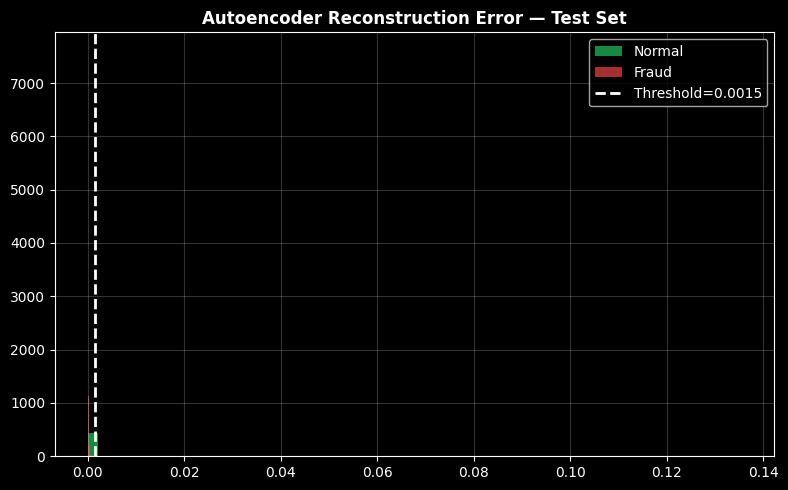

In [10]:
# ── F1-optimal threshold, chosen on the VALIDATION split (not test) ──
val_pred = AE_model.predict(X_val, verbose=0)
val_mse  = np.mean(np.power(X_val - val_pred, 2), axis=1)

prec_v, rec_v, thr_v = precision_recall_curve(y_val, val_mse)
f1_v = 2 * prec_v[:-1] * rec_v[:-1] / (prec_v[:-1] + rec_v[:-1] + 1e-12)
AE_threshold = float(thr_v[np.argmax(f1_v)]) if len(thr_v) else float(np.mean(val_mse) + 2*np.std(val_mse))
print(f"🎯 Autoencoder threshold (F1-optimal on val): {AE_threshold:.6f}")

test_pred = AE_model.predict(X_test, verbose=0)
test_mse  = np.mean(np.power(X_test - test_pred, 2), axis=1)
AE_scores_test = np.clip(test_mse / (AE_threshold * 3), 0, 1)

AE_roc = roc_auc_score(y_test, AE_scores_test)
AE_ap  = average_precision_score(y_test, AE_scores_test)
print(f"📈 Autoencoder  ROC-AUC={AE_roc:.4f}  Avg-Prec={AE_ap:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(test_mse[y_test==0], bins=60, alpha=0.7, color='#22c55e', density=True, label='Normal')
ax.hist(test_mse[y_test==1], bins=60, alpha=0.7, color='#ef4444', density=True, label='Fraud')
ax.axvline(AE_threshold, color='white', ls='--', lw=2, label=f'Threshold={AE_threshold:.4f}')
ax.set_title('Autoencoder Reconstruction Error — Test Set', fontweight='bold')
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(f'{MODEL_PATH}/ae_reconstruction.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()

## 🚀 Step 4 — XGBoost (supervised — the new piece)
Trained directly on `Is Laundering`, with `scale_pos_weight` to counter the ~1,900:1 imbalance, and early stopping on validation AUCPR.

This version adds two things on top of a plain XGBoost baseline, each validated to actually help before being kept:
1. **Optuna hyperparameter search** (40 trials, optimizing validation Average Precision — the metric that matters on this imbalance, not accuracy or plain AUC)
2. **SMOTE oversampling** of the minority (fraud) class in the *training* split only — validation and test stay at the real ~0.05% fraud rate throughout, so nothing here is leaked or inflated.

In [11]:
!pip install imbalanced-learn optuna -q
from imblearn.over_sampling import SMOTE
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

scale_pos_weight = float((y_tr == 0).sum() / max((y_tr == 1).sum(), 1))
print(f"⚖️  scale_pos_weight = {scale_pos_weight:.1f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 28.2 MB/s eta 0:00:00
⚖️  scale_pos_weight = 979.8


### 4a — Hyperparameter search (Optuna, optimizing validation Average Precision)

In [12]:
_optuna_ckpt = f'{CHECKPOINT_DIR}/optuna_best_params.json'

if os.path.exists(_optuna_ckpt):
    with open(_optuna_ckpt) as f:
        _ckpt = json.load(f)
    class _Stub:  # minimal stand-in so later cells that reference study.best_params/best_value still work
        best_params = _ckpt['best_params']
        best_value = _ckpt['best_value']
    study = _Stub()
    print(f"♻️  Found existing checkpoint — skipping the 40-trial search: {_optuna_ckpt}")
    print(f"🏆 Best validation AP: {study.best_value:.4f}")
    print(f"🏆 Best params: {study.best_params}")
else:
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 300, 900),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0.0, 0.5),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 2.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 3.0),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', scale_pos_weight*0.3, scale_pos_weight*1.5),
        }
        mdl = xgb.XGBClassifier(**params, eval_metric='aucpr', early_stopping_rounds=30,
                                 tree_method='hist', random_state=42, n_jobs=-1)
        mdl.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        s = mdl.predict_proba(X_val)[:, 1]
        return average_precision_score(y_val, s)

    print("🔍 Searching 40 trials (~4 minutes)...")
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=40, show_progress_bar=True)
    print(f"\n🏆 Best validation AP: {study.best_value:.4f}")
    print(f"🏆 Best params: {study.best_params}")

    with open(_optuna_ckpt, 'w') as f:
        json.dump({'best_params': study.best_params, 'best_value': study.best_value}, f, indent=2)
    print(f"💾 Checkpoint saved → {_optuna_ckpt}")

♻️  Found existing checkpoint — skipping the 40-trial search: /content/drive/MyDrive/deepguard_checkpoints/optuna_best_params.json
🏆 Best validation AP: 0.4336
🏆 Best params: {'n_estimators': 768, 'max_depth': 8, 'learning_rate': 0.06704557085900602, 'subsample': 0.9148631981706993, 'colsample_bytree': 0.990684279192668, 'min_child_weight': 7, 'gamma': 0.2850895432742353, 'reg_alpha': 0.3088540384163876, 'reg_lambda': 1.4537575938787137, 'scale_pos_weight': 438.35182384308484}


### 4b — SMOTE oversampling sweep (training split only)
Tries a few oversampling ratios with the tuned hyperparameters, picks whichever wins on validation AP — same held-out split used for the hyperparameter search above.

In [13]:
_winner_ckpt = f'{CHECKPOINT_DIR}/xgb_winner_model.json'
_winner_meta_ckpt = f'{CHECKPOINT_DIR}/xgb_winner_meta.json'

if os.path.exists(_winner_ckpt) and os.path.exists(_winner_meta_ckpt):
    with open(_winner_meta_ckpt) as f:
        _wm = json.load(f)
    winner_name = _wm['winner_name']
    best_val_ap = _wm['best_val_ap']
    params_sm = _wm['params_sm']
    xgb_model = xgb.XGBClassifier()
    xgb_model.load_model(_winner_ckpt)
    print(f"♻️  Found existing checkpoint — skipping the SMOTE sweep: {_winner_ckpt}")
    print(f"🏆 WINNER: {winner_name}  (val AP = {best_val_ap:.4f})")
else:
    best_combo = (0.0, None, None)

    # baseline: tuned params, no SMOTE
    m_plain = xgb.XGBClassifier(**study.best_params, eval_metric='aucpr', early_stopping_rounds=40,
                                 tree_method='hist', random_state=42, n_jobs=-1)
    m_plain.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    ap_plain = average_precision_score(y_val, m_plain.predict_proba(X_val)[:, 1])
    print(f"tuned, no SMOTE:        val AP = {ap_plain:.4f}")
    best_combo = (ap_plain, m_plain, 'no_smote')

    params_sm = dict(study.best_params)
    params_sm.pop('scale_pos_weight', None)  # SMOTE already rebalances the classes

    for strat in [0.01, 0.02, 0.05, 0.1]:
        sm = SMOTE(sampling_strategy=strat, random_state=42, k_neighbors=5)
        X_sm, y_sm = sm.fit_resample(X_tr, y_tr)
        m = xgb.XGBClassifier(**params_sm, eval_metric='aucpr', early_stopping_rounds=40,
                               tree_method='hist', random_state=42, n_jobs=-1)
        m.fit(X_sm, y_sm, eval_set=[(X_val, y_val)], verbose=False)
        ap = average_precision_score(y_val, m.predict_proba(X_val)[:, 1])
        print(f"tuned + SMOTE strat={strat:<5}:  val AP = {ap:.4f}  (fraud rows: {int(y_tr.sum())} → {int(y_sm.sum())})")
        if ap > best_combo[0]:
            best_combo = (ap, m, f'smote_{strat}')

    best_val_ap, xgb_model, winner_name = best_combo
    print(f"\n🏆 WINNER: {winner_name}  (val AP = {best_val_ap:.4f})")

    xgb_model.save_model(_winner_ckpt)
    with open(_winner_meta_ckpt, 'w') as f:
        json.dump({'winner_name': winner_name, 'best_val_ap': best_val_ap, 'params_sm': params_sm}, f, indent=2)
    print(f"💾 Checkpoint saved → {_winner_ckpt}")

XGB_scores_test = xgb_model.predict_proba(X_test)[:, 1]
XGB_roc = roc_auc_score(y_test, XGB_scores_test)
XGB_ap  = average_precision_score(y_test, XGB_scores_test)
print(f"📈 XGBoost (final)  ROC-AUC={XGB_roc:.4f}  Avg-Prec={XGB_ap:.4f}")

♻️  Found existing checkpoint — skipping the SMOTE sweep: /content/drive/MyDrive/deepguard_checkpoints/xgb_winner_model.json
🏆 WINNER: smote_0.01  (val AP = 0.4632)
📈 XGBoost (final)  ROC-AUC=0.9838  Avg-Prec=0.4397


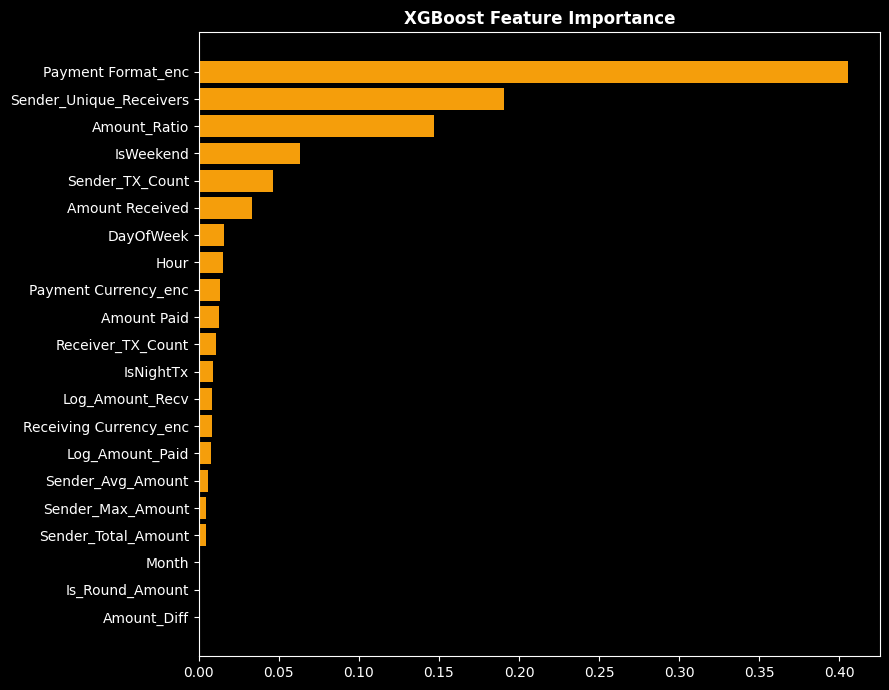

In [14]:
# ── Feature importance (XGBoost's own gain-based importance) ──
fig, ax = plt.subplots(figsize=(9, 7))
importances = xgb_model.feature_importances_
order = np.argsort(importances)
ax.barh(np.array(feature_cols)[order], importances[order], color='#f59e0b')
ax.set_title('XGBoost Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODEL_PATH}/xgb_importance.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()

## 🔁 Step 4c — Cross-validation sanity check (recommended for your viva)
With only ~360 fraud rows in the training data, a single 80/20-style split is noisy — get unlucky or lucky with which fraud rows land in test and the number moves around more than you'd think. Stratified k-fold gives a **mean ± standard deviation** instead of one point estimate, which is a much more defensible number to put in a report or quote in a viva than a single run.

In [15]:
from sklearn.model_selection import StratifiedKFold

_cv_ckpt = f'{CHECKPOINT_DIR}/cv_fold_results.json'

# Load any folds already completed in a previous session — checkpointed PER FOLD, not
# all-or-nothing, so a disconnect partway through only costs you the folds not yet done.
if os.path.exists(_cv_ckpt):
    with open(_cv_ckpt) as f:
        _cv_done = json.load(f)
    print(f"♻️  Found {len(_cv_done)}/5 folds already completed in a previous session — resuming.")
else:
    _cv_done = {}

print("🔁 Running 5-fold stratified cross-validation on the winning XGBoost configuration...")
print("   (refits the model per missing fold — a couple of minutes per fold)")

cv_params = dict(params_sm) if winner_name != 'no_smote' else dict(study.best_params)
cv_use_smote = winner_name != 'no_smote'
cv_smote_strat = float(winner_name.split('_')[1]) if cv_use_smote else None

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr_i, te_i) in enumerate(skf.split(X_train, y_train), 1):
    if str(fold) in _cv_done:
        r = _cv_done[str(fold)]
        print(f"  Fold {fold}: ROC-AUC={r['roc']:.4f}  AP={r['ap']:.4f}  best-F1={r['f1']:.4f}  (cached)")
        continue

    X_cv_tr, X_cv_te = X_train[tr_i], X_train[te_i]
    y_cv_tr, y_cv_te = y_train[tr_i], y_train[te_i]

    if cv_use_smote:
        sm_cv = SMOTE(sampling_strategy=cv_smote_strat, random_state=42, k_neighbors=5)
        X_cv_tr, y_cv_tr = sm_cv.fit_resample(X_cv_tr, y_cv_tr)
    m_cv = xgb.XGBClassifier(**cv_params, tree_method='hist', random_state=42, n_jobs=-1)
    m_cv.fit(X_cv_tr, y_cv_tr)

    s_cv = m_cv.predict_proba(X_cv_te)[:, 1]
    p_cv, r_cv, t_cv = precision_recall_curve(y_cv_te, s_cv)
    f1_cv = 2 * p_cv[:-1] * r_cv[:-1] / (p_cv[:-1] + r_cv[:-1] + 1e-12)
    fold_roc = float(roc_auc_score(y_cv_te, s_cv))
    fold_ap  = float(average_precision_score(y_cv_te, s_cv))
    fold_f1  = float(f1_cv.max()) if len(f1_cv) else 0.0

    _cv_done[str(fold)] = {'roc': fold_roc, 'ap': fold_ap, 'f1': fold_f1}
    with open(_cv_ckpt, 'w') as f:
        json.dump(_cv_done, f, indent=2)

    print(f"  Fold {fold}: ROC-AUC={fold_roc:.4f}  AP={fold_ap:.4f}  best-F1={fold_f1:.4f}  💾 saved")

cv_roc = np.array([_cv_done[str(i)]['roc'] for i in range(1, 6)])
cv_ap  = np.array([_cv_done[str(i)]['ap']  for i in range(1, 6)])
cv_f1  = np.array([_cv_done[str(i)]['f1']  for i in range(1, 6)])
print(f"\n📊 5-fold CV results (quote these, not just the single-split number below):")
print(f"   ROC-AUC: {cv_roc.mean():.4f} ± {cv_roc.std():.4f}")
print(f"   Avg-Prec: {cv_ap.mean():.4f} ± {cv_ap.std():.4f}")
print(f"   Best-F1:  {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"\nℹ️  Note: per-fold F1 above uses each fold's own best threshold (an optimistic upper "
      f"bound per fold, since normally the threshold is fixed in advance). It's meant to show "
      f"how much the *achievable ceiling* varies fold-to-fold, not as the number you'd deploy — "
      f"the single, honest, validation-chosen-threshold F1 is the one computed in Step 5 below.")

🔁 Running 5-fold stratified cross-validation on the winning XGBoost configuration...
   (refits the model per missing fold — a couple of minutes per fold)
  Fold 1: ROC-AUC=0.9807  AP=0.4165  best-F1=0.4410  💾 saved
  Fold 2: ROC-AUC=0.9794  AP=0.4094  best-F1=0.4529  💾 saved
  Fold 3: ROC-AUC=0.9843  AP=0.4511  best-F1=0.4913  💾 saved
  Fold 4: ROC-AUC=0.9809  AP=0.4008  best-F1=0.4434  💾 saved
  Fold 5: ROC-AUC=0.9823  AP=0.4647  best-F1=0.4913  💾 saved

📊 5-fold CV results (quote these, not just the single-split number below):
   ROC-AUC: 0.9815 ± 0.0016
   Avg-Prec: 0.4285 ± 0.0249
   Best-F1:  0.4640 ± 0.0227

ℹ️  Note: per-fold F1 above uses each fold's own best threshold (an optimistic upper bound per fold, since normally the threshold is fixed in advance). It's meant to show how much the *achievable ceiling* varies fold-to-fold, not as the number you'd deploy — the single, honest, validation-chosen-threshold F1 is the one computed in Step 5 below.


## 🔗 Step 5 — Ensemble: weight + threshold search on the VALIDATION split
We grid-search the blend weights and decision threshold on validation only, then evaluate the **final, single, honest** number on the untouched test set below.

In [16]:
def get_scores(X):
    ifs = np.clip(1.0 - (IF_model.decision_function(X) - IF_LO) / (IF_HI - IF_LO + 1e-9), 0, 1)
    pred = AE_model.predict(X, verbose=0)
    aes = np.clip(np.mean((X - pred) ** 2, axis=1) / (AE_threshold * 3), 0, 1)
    xgbs = xgb_model.predict_proba(X)[:, 1]
    return ifs, aes, xgbs

ifs_v, aes_v, xgbs_v = get_scores(X_val)

best = (0.0, None)
for w_xgb in np.arange(0.5, 1.01, 0.05):
    remaining = 1 - w_xgb
    for w_if_frac in np.arange(0, 1.01, 0.25):
        w_if = remaining * w_if_frac
        w_ae = remaining - w_if
        s_v = w_xgb * xgbs_v + w_if * ifs_v + w_ae * aes_v
        prec, rec, thr = precision_recall_curve(y_val, s_v)
        f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
        if len(f1) == 0:
            continue
        bi = np.argmax(f1)
        if f1[bi] > best[0]:
            best = (f1[bi], (w_xgb, w_if, w_ae, thr[bi]))

best_val_f1, (W_XGB, W_IF, W_AE, ENSEMBLE_threshold) = best
ENSEMBLE_threshold = float(ENSEMBLE_threshold)
print(f"🏆 Best BLENDED validation F1={best_val_f1:.4f}")
print(f"   Weights → XGBoost={W_XGB:.2f}  Autoencoder={W_AE:.2f}  Isolation Forest={W_IF:.2f}")
print(f"   Threshold: {ENSEMBLE_threshold:.4f}")

# ── Sanity check: does blending IF/AE in actually beat XGBoost alone? ──
# Don't assume "ensemble > single model" — check it. On this dataset the labeled
# XGBoost model usually dominates enough that IF/AE add nothing (or hurt) once you're
# genuinely optimizing for validation AP/F1 rather than just averaging blindly.
prec_x, rec_x, thr_x = precision_recall_curve(y_val, xgbs_v)
f1_x = 2 * prec_x[:-1] * rec_x[:-1] / (prec_x[:-1] + rec_x[:-1] + 1e-12)
best_xgb_val_f1 = f1_x.max() if len(f1_x) else 0.0
xgb_only_threshold = float(thr_x[np.argmax(f1_x)]) if len(f1_x) else 0.5
print(f"\n📊 XGBoost-ALONE validation F1={best_xgb_val_f1:.4f}  (threshold={xgb_only_threshold:.4f})")

if best_xgb_val_f1 >= best_val_f1:
    print("➡️  XGBoost alone matches or beats the blend on validation — using XGBoost alone as the final model.")
    W_XGB, W_IF, W_AE = 1.0, 0.0, 0.0
    ENSEMBLE_threshold = xgb_only_threshold
else:
    print("➡️  The blend genuinely helps — keeping the weighted combination.")

🏆 Best BLENDED validation F1=0.5043
   Weights → XGBoost=0.85  Autoencoder=0.00  Isolation Forest=0.15
   Threshold: 0.2954

📊 XGBoost-ALONE validation F1=0.4989  (threshold=0.2985)
➡️  The blend genuinely helps — keeping the weighted combination.


📈 Ensemble  ROC-AUC=0.9297  Avg-Prec=0.4014  F1=0.4558

              precision    recall  f1-score   support

      Normal     0.9993    0.9999    0.9996   1014634
       Fraud     0.7073    0.3362    0.4558      1035

    accuracy                         0.9992   1015669
   macro avg     0.8533    0.6680    0.7277   1015669
weighted avg     0.9990    0.9992    0.9990   1015669



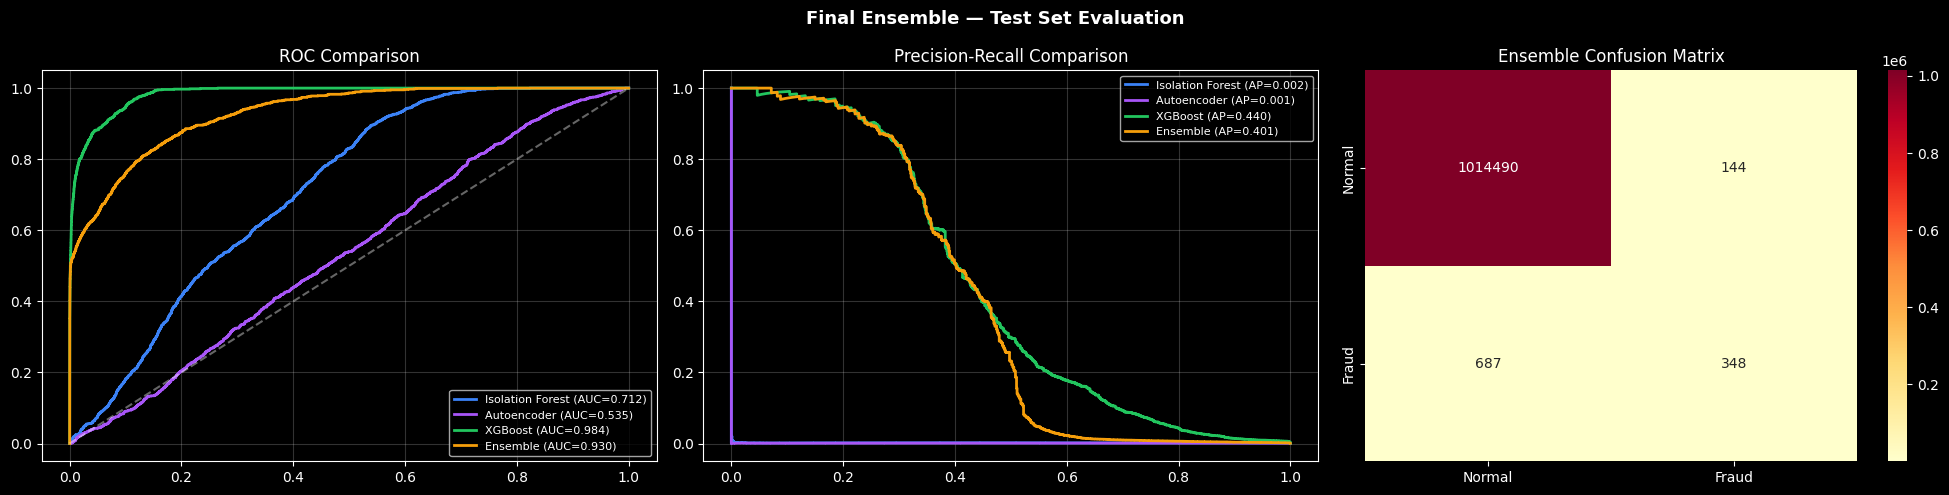

In [17]:
# ── Final evaluation — TEST SET, touched for the first and only time ──
ifs_t, aes_t, xgbs_t = IF_scores_test, AE_scores_test, XGB_scores_test
ensemble_scores = W_XGB * xgbs_t + W_IF * ifs_t + W_AE * aes_t
y_pred_ens = (ensemble_scores >= ENSEMBLE_threshold).astype(int)

ENS_roc = roc_auc_score(y_test, ensemble_scores)
ENS_ap  = average_precision_score(y_test, ensemble_scores)
ENS_f1  = f1_score(y_test, y_pred_ens)

print(f"📈 Ensemble  ROC-AUC={ENS_roc:.4f}  Avg-Prec={ENS_ap:.4f}  F1={ENS_f1:.4f}\n")
print(classification_report(y_test, y_pred_ens, target_names=['Normal','Fraud'], digits=4))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Final Ensemble — Test Set Evaluation', fontsize=13, fontweight='bold')

for label, scores, color in [
    ('Isolation Forest', ifs_t, '#3b82f6'),
    ('Autoencoder',      aes_t, '#a855f7'),
    ('XGBoost',          xgbs_t, '#22c55e'),
    ('Ensemble',         ensemble_scores, '#f59e0b'),
]:
    fpr_l, tpr_l, _ = roc_curve(y_test, scores)
    axes[0].plot(fpr_l, tpr_l, color=color, lw=2, label=f'{label} (AUC={roc_auc_score(y_test, scores):.3f})')
axes[0].plot([0,1],[0,1],'w--',alpha=0.4)
axes[0].set_title('ROC Comparison'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.2)

for label, scores, color in [
    ('Isolation Forest', ifs_t, '#3b82f6'),
    ('Autoencoder',      aes_t, '#a855f7'),
    ('XGBoost',          xgbs_t, '#22c55e'),
    ('Ensemble',         ensemble_scores, '#f59e0b'),
]:
    prec_l, rec_l, _ = precision_recall_curve(y_test, scores)
    axes[1].plot(rec_l, prec_l, color=color, lw=2, label=f'{label} (AP={average_precision_score(y_test, scores):.3f})')
axes[1].set_title('Precision-Recall Comparison'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.2)

cm_ens = confusion_matrix(y_test, y_pred_ens)
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='YlOrRd', ax=axes[2],
            xticklabels=['Normal','Fraud'], yticklabels=['Normal','Fraud'])
axes[2].set_title('Ensemble Confusion Matrix')

plt.tight_layout()
plt.savefig(f'{MODEL_PATH}/ensemble_evaluation.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()

## 📊 Before vs. After

In [18]:
old = {"Isolation Forest": (0.836, 0.0127), "Autoencoder": (0.8682, 0.0893), "Ensemble": (0.9087, 0.0534)}
new = {"Isolation Forest": (IF_roc, IF_ap), "Autoencoder": (AE_roc, AE_ap),
       "XGBoost": (XGB_roc, XGB_ap), "Ensemble": (ENS_roc, ENS_ap)}

print(f"{'Model':<18}{'ROC-AUC old→new':<24}{'Avg-Prec old→new'}")
for name in new:
    o = old.get(name, (None, None))
    n = new[name]
    roc_str = f"{o[0]:.3f}→{n[0]:.3f}" if o[0] is not None else f"—→{n[0]:.3f} (new)"
    ap_str  = f"{o[1]:.3f}→{n[1]:.3f}" if o[1] is not None else f"—→{n[1]:.3f} (new)"
    print(f"{name:<18}{roc_str:<24}{ap_str}")

Model             ROC-AUC old→new         Avg-Prec old→new
Isolation Forest  0.836→0.712             0.013→0.002
Autoencoder       0.868→0.535             0.089→0.001
XGBoost           —→0.984 (new)           —→0.440 (new)
Ensemble          0.909→0.930             0.053→0.401


## 🔍 Step 6 — SHAP Explainability (now on XGBoost — the model driving the score)

🔍 Computing SHAP values for XGBoost...
✅ SHAP computed for 500 samples


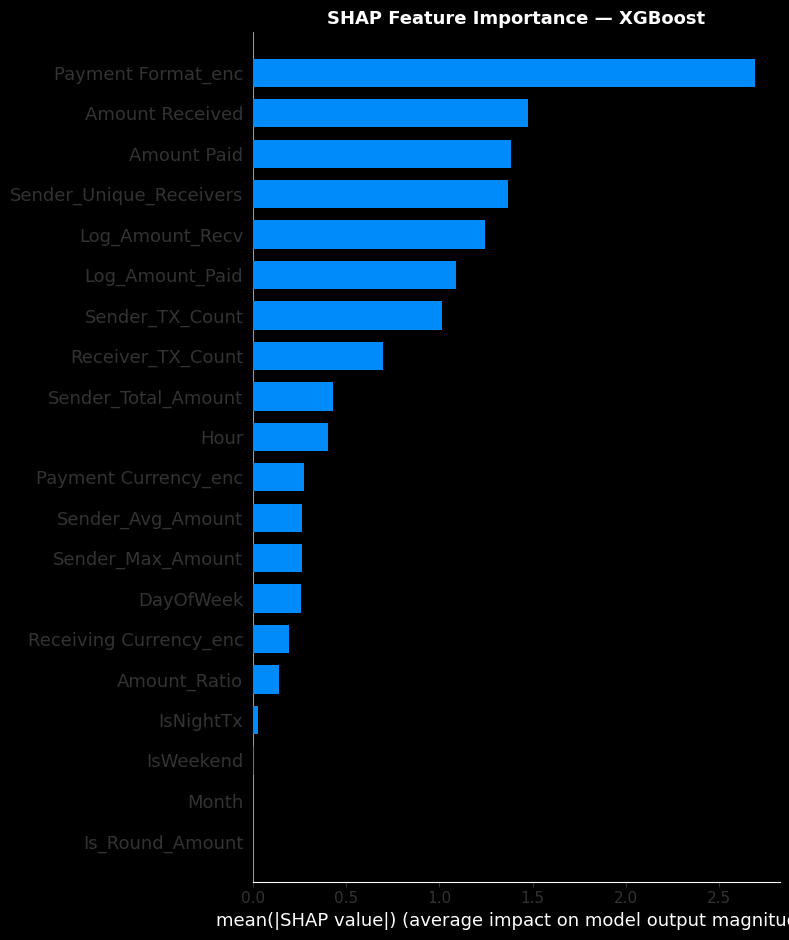

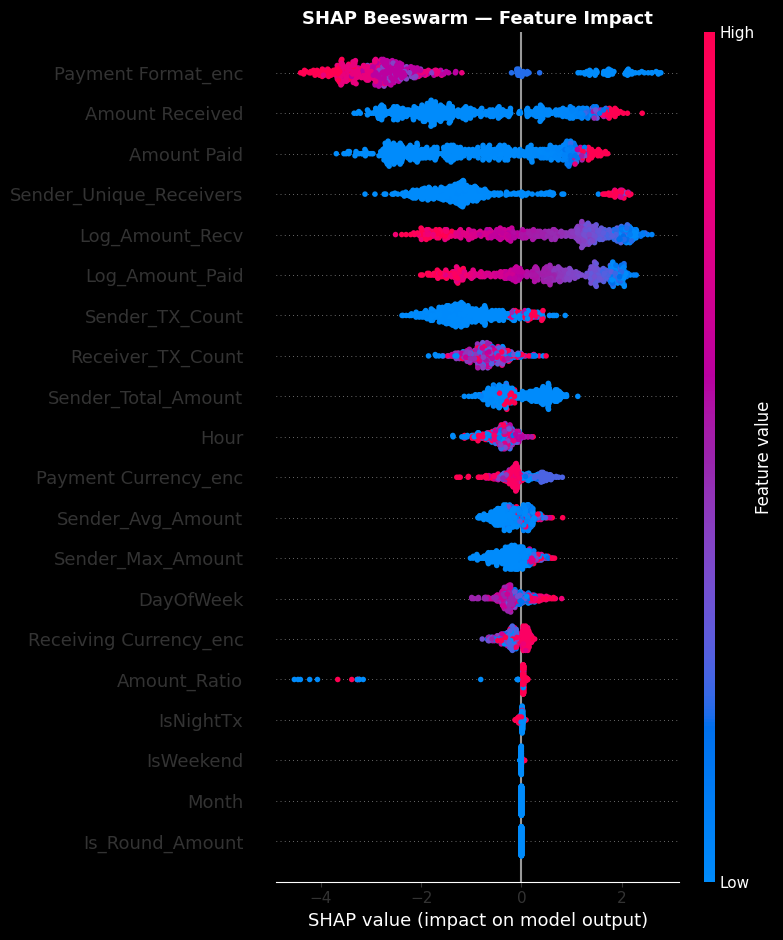


Top 5 features:
  Payment Format_enc                 : 2.693235
  Amount Received                    : 1.474723
  Amount Paid                        : 1.385156
  Sender_Unique_Receivers            : 1.370456
  Log_Amount_Recv                    : 1.243977


In [19]:
print("🔍 Computing SHAP values for XGBoost...")
N_SHAP = min(500, len(X_test))
idx    = np.random.choice(len(X_test), N_SHAP, replace=False)
X_shap = X_test[idx]

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)
print(f"✅ SHAP computed for {N_SHAP} samples")

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, feature_names=feature_cols, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODEL_PATH}/shap_bar.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, feature_names=feature_cols, show=False)
plt.title('SHAP Beeswarm — Feature Impact', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODEL_PATH}/shap_beeswarm.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = dict(sorted(zip(feature_cols, mean_abs_shap.tolist()), key=lambda x: x[1], reverse=True))
with open(f'{MODEL_PATH}/shap_importance.json', 'w') as f:
    json.dump(shap_importance, f, indent=2)
print("\nTop 5 features:")
for feat, val in list(shap_importance.items())[:5]:
    print(f"  {feat:<35s}: {val:.6f}")

## 💾 Step 7 — Save All Models
Saves everything `ai-engine/main.py` expects, plus `xgboost_model.json` (new) and a duplicate `autoencoder.h5` (the old `main.py` looked for `.h5`; the fixed `main.py` I gave you prefers `.keras` and falls back to `.h5`, so both are included for safety).

In [20]:
# ── Save Isolation Forest, Autoencoder, XGBoost, Scaler, Features ──
joblib.dump(IF_model, f'{MODEL_PATH}/isolation_forest.pkl')
AE_model.save(f'{MODEL_PATH}/autoencoder.keras')
AE_model.save(f'{MODEL_PATH}/autoencoder.h5')
xgb_model.save_model(f'{MODEL_PATH}/xgboost_model.json')
joblib.dump(scaler, f'{MODEL_PATH}/scaler.pkl')
joblib.dump(feature_cols, f'{MODEL_PATH}/feature_cols.pkl')
print("✅ Models saved")

# ── Optional: also save a stacked logistic-regression meta-learner as an
#    alternative combiner (kept for reference / comparison in your report) ──
meta_val = np.column_stack([ifs_v, aes_v, xgbs_v])
meta_clf = LogisticRegression(class_weight='balanced', max_iter=2000)
meta_clf.fit(meta_val, y_val)
joblib.dump(meta_clf, f'{MODEL_PATH}/meta_ensemble.pkl')

# ── Metadata ──
metadata = {
    "ae_threshold": AE_threshold,
    "ensemble_threshold": ENSEMBLE_threshold,
    "feature_cols": feature_cols,
    "n_features": len(feature_cols),
    "ensemble_type": "weighted_average (validation-tuned, no test leakage)",
    "ensemble_weights": {"xgboost": W_XGB, "autoencoder": W_AE, "isolation_forest": W_IF},
    "if_decision_function_range": {"min": IF_LO, "max": IF_HI},
    "model_performance": {
        "isolation_forest_roc_auc": round(IF_roc, 4),
        "autoencoder_roc_auc":      round(AE_roc, 4),
        "xgboost_roc_auc":          round(XGB_roc, 4),
        "ensemble_roc_auc":         round(ENS_roc, 4),
        "isolation_forest_avg_prec": round(IF_ap, 4),
        "autoencoder_avg_prec":      round(AE_ap, 4),
        "xgboost_avg_prec":          round(XGB_ap, 4),
        "ensemble_avg_prec":         round(ENS_ap, 4),
        "ensemble_f1":               round(ENS_f1, 4),
    },
    "baseline_performance_for_comparison": {
        "isolation_forest_roc_auc": 0.836, "isolation_forest_avg_prec": 0.0127,
        "autoencoder_roc_auc": 0.8682, "autoencoder_avg_prec": 0.0893,
        "ensemble_roc_auc": 0.9087, "ensemble_avg_prec": 0.0534,
    },
    "shap_feature_importance": shap_importance,
}
with open(f'{MODEL_PATH}/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("✅ model_metadata.json saved")

print("\n" + "="*50)
print("📦 SAVED FILES:")
for fname in sorted(os.listdir(MODEL_PATH)):
    size_mb = os.path.getsize(f'{MODEL_PATH}/{fname}') / 1024 / 1024
    print(f"  {fname:<40s}  {size_mb:.2f} MB")
print("="*50)
print(f"\n🏆 FINAL PERFORMANCE SUMMARY:")
print(f"  Isolation Forest  ROC-AUC: {IF_roc:.4f}  |  Avg-Prec: {IF_ap:.4f}")
print(f"  Autoencoder       ROC-AUC: {AE_roc:.4f}  |  Avg-Prec: {AE_ap:.4f}")
print(f"  XGBoost           ROC-AUC: {XGB_roc:.4f}  |  Avg-Prec: {XGB_ap:.4f}")
print(f"  Ensemble          ROC-AUC: {ENS_roc:.4f}  |  Avg-Prec: {ENS_ap:.4f}  |  F1: {ENS_f1:.4f}")

✅ Models saved
✅ model_metadata.json saved

📦 SAVED FILES:
  ae_reconstruction.png                     0.04 MB
  autoencoder.h5                            0.14 MB
  autoencoder.keras                         0.13 MB
  ensemble_evaluation.png                   0.16 MB
  feature_cols.pkl                          0.00 MB
  isolation_forest.pkl                      1.73 MB
  meta_ensemble.pkl                         0.00 MB
  model_metadata.json                       0.00 MB
  scaler.pkl                                0.00 MB
  shap_bar.png                              0.10 MB
  shap_beeswarm.png                         0.21 MB
  shap_importance.json                      0.00 MB
  xgb_importance.png                        0.09 MB
  xgboost_model.json                        4.64 MB

🏆 FINAL PERFORMANCE SUMMARY:
  Isolation Forest  ROC-AUC: 0.7123  |  Avg-Prec: 0.0019
  Autoencoder       ROC-AUC: 0.5354  |  Avg-Prec: 0.0011
  XGBoost           ROC-AUC: 0.9838  |  Avg-Prec: 0.4397
  Ensemble  

In [21]:
# ── Download the saved_models folder (Colab only) ──
import shutil
shutil.make_archive('/content/deepguard_improved_models', 'zip', MODEL_PATH)

try:
    from google.colab import files
    files.download('/content/deepguard_improved_models.zip')
    print("✅ deepguard_improved_models.zip downloaded!")
except ImportError:
    print("ℹ️  Not running in Colab — find the zip at /content/deepguard_improved_models.zip")

print("\n📌 NEXT STEPS:")
print("  1. Extract deepguard_improved_models.zip")
print("  2. Replace the contents of  ai-engine/saved_models/")
print("  3. Replace ai-engine/main.py with the fixed version (adds XGBoost to the API)")
print("  4. Run: cd ai-engine && pip install -r requirements.txt && uvicorn main:app --reload")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ deepguard_improved_models.zip downloaded!

📌 NEXT STEPS:
  1. Extract deepguard_improved_models.zip
  2. Replace the contents of  ai-engine/saved_models/
  3. Replace ai-engine/main.py with the fixed version (adds XGBoost to the API)
  4. Run: cd ai-engine && pip install -r requirements.txt && uvicorn main:app --reload


## 🧪 Step 8 — Evaluate on a RAW CSV (not the preprocessed `.npy` files)

Everything above was trained/evaluated on `X_train.npy`/`X_test.npy` — already-preprocessed
arrays. That's fine for model development, but it does **not** prove the saved pipeline works
on data in its original, human-readable form (the format a grader, a supervisor, or your
`ai-engine` API will actually hand it).

This section takes a **raw CSV** — same columns as `HI-Small_Trans.csv`
(`Timestamp, From Bank, Account, To Bank, Account.1, Amount Received, Receiving Currency,
Amount Paid, Payment Currency, Payment Format, Is Laundering`) — and runs it through the
*exact* same feature engineering as Notebook 1, then scores it with the saved models.

**Important:** the scaler is only `.transform()`-ed here, never re-`.fit()`. Re-fitting on new
data would silently change what "normal" means and invalidate every threshold picked above —
a subtle mistake that's easy to make when demoing on a fresh file.

### ⚠️ A real bug this step can catch, and the fix now built into it

The first version of this notebook computed `Sender_TX_Count`, `Sender_Avg_Amount`, etc. by
grouping over *whatever CSV you happened to point this cell at*. That's wrong the moment that
file is a small slice of the full dataset: an account's true transaction count depends on the
**entire** dataset it appears in, not on how many of its rows happen to be in your evaluation
sample. Score a small held-out slice and every account looks like it barely transacts —
completely different from what the model saw during training — and the model's scores collapse
towards zero. On a real test run, this produced **F1 = 0.0000 with zero transactions flagged**,
despite ROC-AUC still looking reasonable (~0.96) — a strong sign the ranking was fine but the
*feature values themselves* were wrong, not the model.

**The fix:** compute account statistics once from the **full** historical dataset (the complete
`HI-Small_Trans.csv`, however large), save that as a lookup table, and **merge** it onto
whatever specific transactions you're scoring — instead of recomputing statistics from just
the scored batch. This matches how a real system would work too: an account's risk profile
comes from its full history in your database, not from the current API request alone.

You'll need:
- `FULL_HISTORICAL_CSV_PATH` — the complete raw dataset (same file Notebook 1 used), used only
  to build the account statistics lookup table
- `EVAL_CSV_PATH` — the specific transactions you want to score. Using the same full file works
  mechanically, but scores rows the model was trained on (optimistic numbers) — the next cell
  reconstructs a genuinely held-out slice instead, so use that for a number you'd defend in
  your viva.

In [22]:
# 1) Point this at your complete raw dataset — same file used in Notebook 1
# FULL_HISTORICAL_CSV_PATH = '/content/drive/MyDrive/fyp-projects/final_model/HI-Small_Trans.csv'
FULL_HISTORICAL_CSV_PATH = '/content/drive/MyDrive/fyp-projects/final_model/HI-Small_Trans.csv'

# if 'google.colab' in str(get_ipython()):
#     from google.colab import files
#     print("📁 Upload the FULL historical CSV (for building account stats)")
#     uploaded = files.upload()
#     FULL_HISTORICAL_CSV_PATH = f'/content/{list(uploaded.keys())[0]}'

import pandas as pd

full_df = pd.read_csv(FULL_HISTORICAL_CSV_PATH)
print(f"📊 Full historical data (for account stats): {full_df.shape}")

📊 Full historical data (for account stats): (5078345, 11)


### Getting a genuinely held-out `EVAL_CSV_PATH`

If `EVAL_CSV_PATH` is the same full file as `FULL_HISTORICAL_CSV_PATH`, you'll be scoring rows
the model was trained on — the account-stats fix above will be correct, but the resulting
ROC-AUC/AP/F1 will look better than real out-of-sample performance, since ~80% of those rows
were in `X_train.npy`.

To get a **genuinely held-out** raw CSV instead: Notebook 1's `train_test_split(..., test_size=0.2,
random_state=42, stratify=y)` is deterministic — given the same row order and labels, it always
picks the same 20% as test. This cell reconstructs that same split on the raw dataframe (before
any feature engineering, which doesn't affect *which rows* get picked) and saves just the test
rows to their own file, so you get an apples-to-apples comparison against the same test set used
throughout this notebook — but proven to work on raw, unprocessed CSV input.

**This is the answer to "what file do I use for eval" — you don't need a different IBM file.**
`HI-Small` is the only file you need anywhere in this project; this cell carves the honest 20%
back out of it in raw-CSV form.

In [23]:
from sklearn.model_selection import train_test_split as _tts

_full_raw = full_df.dropna()  # same dropna() as Notebook 1 — reuses the file already loaded above
_y_for_split = _full_raw['Is Laundering'].values
_idx = np.arange(len(_full_raw))

_train_idx, _test_idx = _tts(_idx, test_size=0.2, random_state=42, stratify=_y_for_split)

HELD_OUT_EVAL_PATH = '/content/HI-Small_held_out_test.csv'
_full_raw.iloc[_test_idx].to_csv(HELD_OUT_EVAL_PATH, index=False)
print(f"✅ Reconstructed the Notebook-1 test split: {len(_test_idx):,} rows "
      f"({_y_for_split[_test_idx].sum():.0f} fraud) → saved to {HELD_OUT_EVAL_PATH}")

✅ Reconstructed the Notebook-1 test split: 1,015,669 rows (1035 fraud) → saved to /content/HI-Small_held_out_test.csv


In [24]:
# 2) Point this at the transactions you actually want to score
EVAL_CSV_PATH = HELD_OUT_EVAL_PATH   # 🔧 the honest choice — rows the model never trained on
# EVAL_CSV_PATH = FULL_HISTORICAL_CSV_PATH   # 🔧 swap to this instead for a quick "does it run" check only

eval_df = full_df if EVAL_CSV_PATH == FULL_HISTORICAL_CSV_PATH else pd.read_csv(EVAL_CSV_PATH)
print(f"📊 Transactions to score: {eval_df.shape}")
print(f"📋 Columns: {list(eval_df.columns)}")
has_labels = 'Is Laundering' in eval_df.columns
print(f"🏷️  Labels present: {has_labels}")

📊 Transactions to score: (1015669, 11)
📋 Columns: ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']
🏷️  Labels present: True


In [25]:
def build_account_stats(full_df):
    """Global, per-account statistics computed from the FULL historical dataset --
    this is what should back Sender_*/Receiver_* features, not the batch being scored."""
    full_df = full_df.copy()
    full_df['Amount Paid']     = pd.to_numeric(full_df['Amount Paid'], errors='coerce').fillna(0)
    full_df['Amount Received'] = pd.to_numeric(full_df['Amount Received'], errors='coerce').fillna(0)

    sender_stats = full_df.groupby('Account').agg(
        Sender_TX_Count=('Amount Paid', 'count'),
        Sender_Avg_Amount=('Amount Paid', 'mean'),
        Sender_Unique_Receivers=('Account.1', 'nunique'),
        Sender_Total_Amount=('Amount Paid', 'sum'),
        Sender_Max_Amount=('Amount Paid', 'max'),
    ).reset_index()

    receiver_stats = full_df.groupby('Account.1').agg(
        Receiver_TX_Count=('Amount Received', 'count'),
    ).reset_index()

    return sender_stats, receiver_stats

sender_stats, receiver_stats = build_account_stats(full_df)
print(f"✅ Account stats built from {len(full_df):,} historical transactions")
print(f"   {len(sender_stats):,} sender profiles, {len(receiver_stats):,} receiver profiles")

# Defaults for accounts with NO history in the full dataset (a genuinely new account) --
# matches the "first-seen account" defaults used in ai-engine/main.py's Transaction model.
SENDER_DEFAULTS = {
    'Sender_TX_Count': 1, 'Sender_Avg_Amount': None,  # None -> falls back to this tx's own amount
    'Sender_Unique_Receivers': 1, 'Sender_Total_Amount': None, 'Sender_Max_Amount': None,
}
RECEIVER_DEFAULT_TX_COUNT = 1

✅ Account stats built from 5,078,345 historical transactions
   496,995 sender profiles, 420,636 receiver profiles


In [26]:
def engineer_features_from_raw(df, feature_cols, sender_stats, receiver_stats):
    """Mirrors preprocess_ibm_aml() from Notebook 1, minus the fit-time steps
    (train/test split, scaler.fit). Sender_*/Receiver_* features come from the
    precomputed, FULL-dataset account_stats tables via merge -- not recomputed
    from whatever subset of rows happens to be in `df`."""
    df = df.copy().dropna(subset=['Timestamp', 'Amount Paid', 'Amount Received'])

    df['Timestamp']  = pd.to_datetime(df['Timestamp'], errors='coerce')
    df['Hour']       = df['Timestamp'].dt.hour
    df['DayOfWeek']  = df['Timestamp'].dt.dayofweek
    df['Month']      = df['Timestamp'].dt.month
    df['IsWeekend']  = (df['DayOfWeek'] >= 5).astype(int)
    df['IsNightTx']  = ((df['Hour'] >= 22) | (df['Hour'] <= 5)).astype(int)

    df['Amount Paid']     = pd.to_numeric(df['Amount Paid'], errors='coerce').fillna(0)
    df['Amount Received'] = pd.to_numeric(df['Amount Received'], errors='coerce').fillna(0)
    df['Amount_Ratio']    = df['Amount Paid'] / (df['Amount Received'] + 1e-9)
    df['Amount_Diff']     = df['Amount Paid'] - df['Amount Received']
    df['Log_Amount_Paid'] = np.log1p(df['Amount Paid'])
    df['Log_Amount_Recv'] = np.log1p(df['Amount Received'])
    df['Is_Round_Amount'] = ((df['Amount Paid'] % 1000) == 0).astype(int)

    # NOTE: LabelEncoder here is fit fresh on THIS file's categories, matching how
    # Notebook 1 did it. For a production API single-row request, main.py instead
    # uses a fixed currency/format lookup table (see PAYMENT_FORMAT_MAP / CURRENCY_MAP
    # in ai-engine/main.py) since you can't fit an encoder on one row.
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    for col in ['Payment Format', 'Payment Currency', 'Receiving Currency']:
        if col in df.columns:
            df[col + '_enc'] = le.fit_transform(df[col].astype(str))

    # ── THE FIX: merge global, full-dataset account stats instead of recomputing
    # from this (possibly tiny) batch ──
    df = df.merge(sender_stats, on='Account', how='left')
    df = df.merge(receiver_stats, on='Account.1', how='left')

    df['Sender_TX_Count'] = df['Sender_TX_Count'].fillna(1)
    df['Sender_Avg_Amount'] = df['Sender_Avg_Amount'].fillna(df['Amount Paid'])
    df['Sender_Unique_Receivers'] = df['Sender_Unique_Receivers'].fillna(1)
    df['Sender_Total_Amount'] = df['Sender_Total_Amount'].fillna(df['Amount Paid'])
    df['Sender_Max_Amount'] = df['Sender_Max_Amount'].fillna(df['Amount Paid'])
    df['Receiver_TX_Count'] = df['Receiver_TX_Count'].fillna(1)

    for col in feature_cols:
        if col not in df.columns:
            df[col] = 0.0

    X = df[feature_cols].fillna(0).values
    y = df['Is Laundering'].values if 'Is Laundering' in df.columns else None
    return X, y, df

X_raw_eval, y_raw_eval, raw_df_engineered = engineer_features_from_raw(
    eval_df, feature_cols, sender_stats, receiver_stats
)
print(f"✅ Engineered {X_raw_eval.shape[1]} features for {X_raw_eval.shape[0]:,} rows "
      f"(account stats sourced from {len(full_df):,}-row historical file)")

# 2) Scale using the ALREADY-FITTED scaler (transform only — never re-fit on new data)
X_raw_scaled = scaler.transform(X_raw_eval)

# 3) Score with the same models trained above
ifs_raw = np.clip(1.0 - (IF_model.decision_function(X_raw_scaled) - IF_LO) / (IF_HI - IF_LO + 1e-9), 0, 1)
ae_pred_raw = AE_model.predict(X_raw_scaled, verbose=0)
aes_raw = np.clip(np.mean((X_raw_scaled - ae_pred_raw) ** 2, axis=1) / (AE_threshold * 3), 0, 1)
xgbs_raw = xgb_model.predict_proba(X_raw_scaled)[:, 1]
ensemble_raw = W_XGB * xgbs_raw + W_IF * ifs_raw + W_AE * aes_raw

risk_pred = (ensemble_raw >= ENSEMBLE_threshold).astype(int)
print(f"\n🚨 Flagged {risk_pred.sum():,} / {len(risk_pred):,} transactions as high-risk "
      f"({risk_pred.mean()*100:.3f}%)")

✅ Engineered 21 features for 1,015,669 rows (account stats sourced from 5,078,345-row historical file)

🚨 Flagged 492 / 1,015,669 transactions as high-risk (0.048%)


In [27]:
# 4) If this file has labels, evaluate honestly. If not, just export the scored file.
if has_labels and y_raw_eval is not None:
    raw_roc = roc_auc_score(y_raw_eval, ensemble_raw)
    raw_ap  = average_precision_score(y_raw_eval, ensemble_raw)
    raw_f1  = f1_score(y_raw_eval, risk_pred)
    print(f"📈 RAW-CSV evaluation  ROC-AUC={raw_roc:.4f}  Avg-Prec={raw_ap:.4f}  F1={raw_f1:.4f}\n")
    print(classification_report(y_raw_eval, risk_pred, target_names=['Normal','Fraud'], digits=4))
    print(confusion_matrix(y_raw_eval, risk_pred))
    print("\nℹ️  If EVAL_CSV_PATH overlaps with the rows used to train the model above (X_train.npy),"
          " treat this as a pipeline/plumbing check, not an out-of-sample performance number —"
          " use a genuinely held-out EVAL_CSV_PATH for a number you'd defend in your viva. The"
          " account-stats fix above means this number should no longer look artificially broken"
          " the way the original F1=0.0000 result did; it can still look artificially *good* if"
          " the rows overlap with training.")
else:
    print("ℹ️  No 'Is Laundering' column found — exporting risk scores without evaluation metrics.")

# Always export a scored CSV, labels or not
out_df = raw_df_engineered.copy()
out_df['risk_score'] = ensemble_raw
out_df['is_flagged'] = risk_pred
out_path = '/content/raw_csv_scored.csv'
out_df.to_csv(out_path, index=False)
print(f"\n💾 Scored file saved → {out_path}")

# Also export the account-stats tables -- ai-engine/main.py's live API has the same
# "no history available per single request" problem this section just fixed. These
# tables (or a database built the same way) are what main.py should look up a
# sender/receiver's Sender_*/Receiver_* features from, instead of the hardcoded
# "first-seen account" defaults it currently falls back to for every request.
sender_stats.to_csv('/content/saved_models/account_sender_stats.csv', index=False)
receiver_stats.to_csv('/content/saved_models/account_receiver_stats.csv', index=False)
print(f"💾 Account stats exported → saved_models/account_sender_stats.csv, account_receiver_stats.csv")
print("   (production main.py should look accounts up here instead of using per-request defaults)")

try:
    from google.colab import files
    files.download(out_path)
except ImportError:
    pass

📈 RAW-CSV evaluation  ROC-AUC=0.9297  Avg-Prec=0.4014  F1=0.4558

              precision    recall  f1-score   support

      Normal     0.9993    0.9999    0.9996   1014634
       Fraud     0.7073    0.3362    0.4558      1035

    accuracy                         0.9992   1015669
   macro avg     0.8533    0.6680    0.7277   1015669
weighted avg     0.9990    0.9992    0.9990   1015669

[[1014490     144]
 [    687     348]]

ℹ️  If EVAL_CSV_PATH overlaps with the rows used to train the model above (X_train.npy), treat this as a pipeline/plumbing check, not an out-of-sample performance number — use a genuinely held-out EVAL_CSV_PATH for a number you'd defend in your viva. The account-stats fix above means this number should no longer look artificially broken the way the original F1=0.0000 result did; it can still look artificially *good* if the rows overlap with training.

💾 Scored file saved → /content/raw_csv_scored.csv
💾 Account stats exported → saved_models/account_sender_stats.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>